## Using APIs in Projects


When getting data from APIs, I strongly suggest following a three-step workflow:

1. Write some code that gets data from an API and saves all of the data (if possible) to a file
2. Write a second program (usually a second file) that loads the data from the API, extracts the data that will be useful for analysis, and saves it in a flat file (typically a CSV).
3. Program number 3 loads the CSV file and does the analysis

This approach has a few important benefits.

The first and most important is that often it is difficult to get the same raw data again. For example, some APIs only lets you get the last week. If you are doing analysis a month down the road and decide that you really wish you had saved different metadata, it is too late. By saving as much of the raw data as possible you can change your measures or analysis strategy in the future (or even do additional studies)

The second benefit is that this gives you a nice pipeline, with intermediate files. Instead of including the entire raw data file in the code that does analysis, you only have to load the CSV, which is often much smaller and easier to work with.

This brief lesson will show an example of this workflow, using `atproto` to get data from the Bluesky API.

Note that I'm going to put everything in one file for convenience, but my typical workflow is to put these in separate files and then run each file separately.

## Research Question

What are the main groups of people who post about Purdue?

To answer this question, we will identify the last 1000 people who posted about Purdue. We will then grab all of the recent posts from those people, cluster them based on following relationships, and then use TF-IDF to identify the main topics of discussion for each cluster.

## Program 1 - Data Retrieval

So, we need three main pieces of data:

1. The last 1000 people who posted about Purdue
2. The recent posts from those people
3. The follower network of those people

We'll save each of these to a separate file, so that we can easily change our analysis later if we want to. For example, maybe we want to look at the last 10,000 people who posted about Purdue instead of just 1,000. If we have the data saved, we can easily change our code to analyze the new data without having to worry about how to get it again.

In [5]:
import atproto
import bluesky_auth

at_client = atproto.Client()
at_client.login(bluesky_auth.USERNAME, bluesky_auth.PASSWORD);

We're going to grab all of the recent posts that mention Purdue, until we have 1000 unique posters.

In [5]:
import csv


def get_posts(query, n=100, cursor=None):
    params = {'q': query, 'limit': n}
    if cursor is not None:
        params['cursor'] = cursor
    response = at_client.app.bsky.feed.search_posts(params)
    return response


posters = set()
with open('recent_purdue_posts.csv', 'w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['author', 'text', 'like_count', 'repost_count', 'uri', 'timestamp']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    # Now get 1000 unique posters, and save their posts to the CSV file
    i = 0
    cursor = None
    while True:
        response = get_posts('Purdue', n=100, cursor=cursor)
        cursor = response.cursor
        for post in response.posts:
            if i % 100 == 0:
                print(f'Got {len(posters)} unique posters so far...')
            i += 1
            if post.author.handle not in posters:
                posters.add(post.author.handle)
            # Save as much data as you think you might possibly want, so that you can easily change your analysis later without having to worry about how to get the data again.
            writer.writerow({
                'author': post.author.handle,
                'text': post.record.text,
                'like_count': post.like_count,
                'repost_count': post.repost_count,
                'uri': post.uri,
                'timestamp': post.record.created_at
            })
            if len(posters) >= 1000:
                break
        if len(posters) >= 1000:
            break



Got 0 unique posters so far...
Got 85 unique posters so far...
Got 151 unique posters so far...
Got 219 unique posters so far...
Got 300 unique posters so far...
Got 338 unique posters so far...
Got 392 unique posters so far...
Got 431 unique posters so far...
Got 471 unique posters so far...
Got 516 unique posters so far...
Got 566 unique posters so far...
Got 596 unique posters so far...
Got 625 unique posters so far...
Got 664 unique posters so far...
Got 710 unique posters so far...
Got 751 unique posters so far...
Got 780 unique posters so far...
Got 808 unique posters so far...
Got 855 unique posters so far...
Got 908 unique posters so far...
Got 930 unique posters so far...
Got 966 unique posters so far...
Got 994 unique posters so far...


In [2]:
# Let's take a look at the data we just saved, to make sure it looks right.
import pandas as pd
df = pd.read_csv('recent_purdue_posts.csv')
df.head()

,author,text,like_count,repost_count,uri,timestamp
0,symmering.bsky.social,"Purdue women's volleyball will join Kentucky, ...",0,0,at://did:plc:hbzuhl2aulzwxwm2pc5ozz5t/app.bsky...,2026-02-25T16:04:13.369Z
1,carm1.bsky.social,2 items of interest: \n--Oregon at Purdue WBB ...,0,0,at://did:plc:ihv24f4m2iho67k2u3wqbczl/app.bsky...,2026-02-25T15:46:20.872Z
2,crazzyasss.bsky.social,A get rich scheme created by big Pharma. Big ...,0,0,at://did:plc:wfohpqf6t5qpiluq6g7sgpsl/app.bsky...,2026-02-25T15:13:43.454Z
3,pucvm.bsky.social,"For #NationalFFAWeek, we’re highlighting Dr. B...",0,0,at://did:plc:gf3i2j6njw5siwjyxtwkfcls/app.bsky...,2026-02-25T15:00:45.794646387Z
4,john-m-indy.bsky.social,Yes. IU somehow is 5-5 against Purdue during t...,1,0,at://did:plc:6cb32rgonnzmk4fd22jlnrkv/app.bsky...,2026-02-25T14:44:34.836Z


### Program 2 - Recent Posts

Now, let's get the recent posts from these people. We'll save this in a separate file, to make it easy to adjust our pipeline. I'll also show you how to checkpoint your data retrieval, so that if you have to stop and start again, you don't lose all of your progress.

In [18]:
def get_recent_posts(author, n=100, cursor=None):
    posts = []
    while len(posts) < n:
        response = at_client.get_author_feed(actor=author, limit=100, cursor=cursor)
        posts.extend(response.feed)
        if not response.feed:
            break
        cursor = response.cursor
    return posts


POSTS_PER_POSTER = 100


df = pd.read_csv('recent_purdue_posts.csv')
posters = set(df['author'])
print(f'There are {len(posters)} unique posters.')

# Check if we have already started getting the recent posts for these posters, and if so, load the list of posters we've already gotten.
try:
    with open('posters_other_posts.csv', 'r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        retrieved_posters = set([row['poster'] for row in reader])
except FileNotFoundError:
    retrieved_posters = set()

with open('posters_other_posts.csv', 'a', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['poster', 'author', 'text', 'like_count', 'repost_count', 'uri']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    i = len(retrieved_posters)
    if len(retrieved_posters) == 0:
        writer.writeheader()
    for poster in posters:
        if poster in retrieved_posters:
            continue
        posts = get_recent_posts(poster, n=POSTS_PER_POSTER)
        for feed_item in posts:
            post = feed_item.post
            writer.writerow({
                'poster': poster,
                'author': post.author.handle,
                'text': post.record.text,
                'like_count': post.like_count,
                'repost_count': post.repost_count,
                'uri': post.uri
            })
        i += 1
        if i % 50 == 0:
            print(f'Finished processing {i} posters.')

There are 1000 unique posters.
Finished processing 250 posters.
Finished processing 300 posters.
Finished processing 350 posters.
Finished processing 400 posters.
Finished processing 450 posters.
Finished processing 500 posters.
Finished processing 550 posters.
Finished processing 600 posters.
Finished processing 650 posters.
Finished processing 700 posters.
Finished processing 750 posters.
Finished processing 800 posters.
Finished processing 850 posters.
Finished processing 900 posters.
Finished processing 950 posters.
Finished processing 1000 posters.


In [ ]:
recent_posts_df = pd.read_csv('posters_other_posts.csv')
recent_posts_df

,poster,author,text,like_count,repost_count,uri
0,1gregtodd.bsky.social,1gregtodd.bsky.social,NaN,0,0,at://did:plc:iohbateayghxus42enyazewi/app.bsky...
1,1gregtodd.bsky.social,atrupar.com,"Warnock: ""We heard tonight the rumblings of a ...",12249,2784,at://did:plc:4llrhdclvdlmmynkwsmg5tdc/app.bsky...
2,1gregtodd.bsky.social,cwebbonline.com,HERO 🔥\n\nAnd I don’t want to hear shit about ...,15272,3722,at://did:plc:uo2fna47c4v6zcnklxfhcvjb/app.bsky...
3,1gregtodd.bsky.social,thedailyshow.com,"""Holy shit, did WE ever make the right decisio...",23271,3176,at://did:plc:7tyhlziszrunowfvarla52va/app.bsky...
4,1gregtodd.bsky.social,petebuttigieg.bsky.social,"In tonight's speech, the president did what he...",15635,3603,at://did:plc:2q2hs5o42jhbd23pp6lkiauh/app.bsky...
...,...,...,...,...,...,...
118010,mikevmos.bsky.social,mikevmos.bsky.social,So they're doing an open shoot around for men'...,0,0,at://did:plc:ndjqvmkej42tbdv7gtouaqte/app.bsky...
118011,mikevmos.bsky.social,mikevmos.bsky.social,This color guy on FS1 has mentioned Northweste...,0,0,at://did:plc:ndjqvmkej42tbdv7gtouaqte/app.bsky...
118012,mikevmos.bsky.social,mikevmos.bsky.social,Article I just read about Canada-USA on Sunday...,0,0,at://did:plc:ndjqvmkej42tbdv7gtouaqte/app.bsky...
118013,mikevmos.bsky.social,mikevmos.bsky.social,02/20/26\n\nGM1: Royals (1-0) 7 Rangers 3\n\n#...,0,0,at://did:plc:ndjqvmkej42tbdv7gtouaqte/app.bsky...


### Program 3 - Follower Network

Finally, we'll get the follower network of these people. This will allow us to cluster them based on who follows whom, which can give us insights into the different groups of people who are posting about Purdue.

This will take a while, so we'll save this data to a file as well.

Note that the code below only saves the followers who have also posted about Purdue. It might be a better idea to save all of the followers, in case you wanted to do a different analysis later.

In [22]:
import pandas as pd
import csv
import time

def get_all_follows(client, handle):
    # Get all of the accounts the user follows, handling pagination
    follows = []
    cursor = None
    while True:
        response = client.get_follows(handle, limit=100, cursor=cursor)
        follows.extend(response.follows)
        if response.cursor is None:
            break
        cursor = response.cursor
    return follows

df = pd.read_csv('recent_purdue_posts.csv')
posters = set(df['author'])

try:
    with open('follow_network.csv', 'r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        retrieved_posters = set([row['from'] for row in reader])
except FileNotFoundError:
    retrieved_posters = set()

# Get all of the accounts the top posters follow, and see which of the top posters follow each other.
with open('follow_network.csv', 'a', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['from', 'to']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    if len(retrieved_posters) == 0:
        writer.writeheader()
    i = len(retrieved_posters)
    for poster in posters:
        if poster in retrieved_posters:
            continue
        follows = get_all_follows(at_client, poster)
        for f in follows:
            if f.handle in posters:
                writer.writerow({'from': poster, 'to': f.handle})
        i += 1
        if i % 50 == 0:
            print(f"Processed {i} posters out of {len(posters)}.")
            time.sleep(20)  # Sleep for a bit to avoid hitting rate limits

Processed 500 posters out of 1000.
Processed 550 posters out of 1000.
Processed 600 posters out of 1000.
Processed 650 posters out of 1000.
Processed 700 posters out of 1000.
Processed 750 posters out of 1000.
Processed 800 posters out of 1000.
Processed 850 posters out of 1000.
Processed 900 posters out of 1000.
Processed 950 posters out of 1000.
Processed 1000 posters out of 1000.


In [23]:
df = pd.read_csv('follow_network.csv')
df.head()

,from,to
0,1011now.com,ksnblocal4.com
1,paulguinnessy.bsky.social,nuclearanna.bsky.social
2,paulguinnessy.bsky.social,audrajwolfe.bsky.social
3,paulguinnessy.bsky.social,scholarlypub.bsky.social
4,paulguinnessy.bsky.social,clancyny.bsky.social


## Analysis

Now, we'll load the follower network and do some clustering. We'll use a simple community detection algorithm to identify clusters of people who follow each other, and then we'll use TF-IDF to identify the main topics of discussion for each cluster.

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(df, source='from', target='to')
communities = nx.community.greedy_modularity_communities(G)
for i, community in enumerate(communities):
    print(f'Community {i}: {len(community)} members')


Community 0: 288 members
Community 1: 183 members
Community 2: 175 members
Community 3: 116 members
Community 4: 10 members
Community 5: 6 members
Community 6: 4 members
Community 7: 3 members
Community 8: 3 members
Community 9: 3 members
Community 10: 2 members
Community 11: 2 members
Community 12: 2 members
Community 13: 2 members
Community 14: 2 members
Community 15: 2 members
Community 16: 2 members


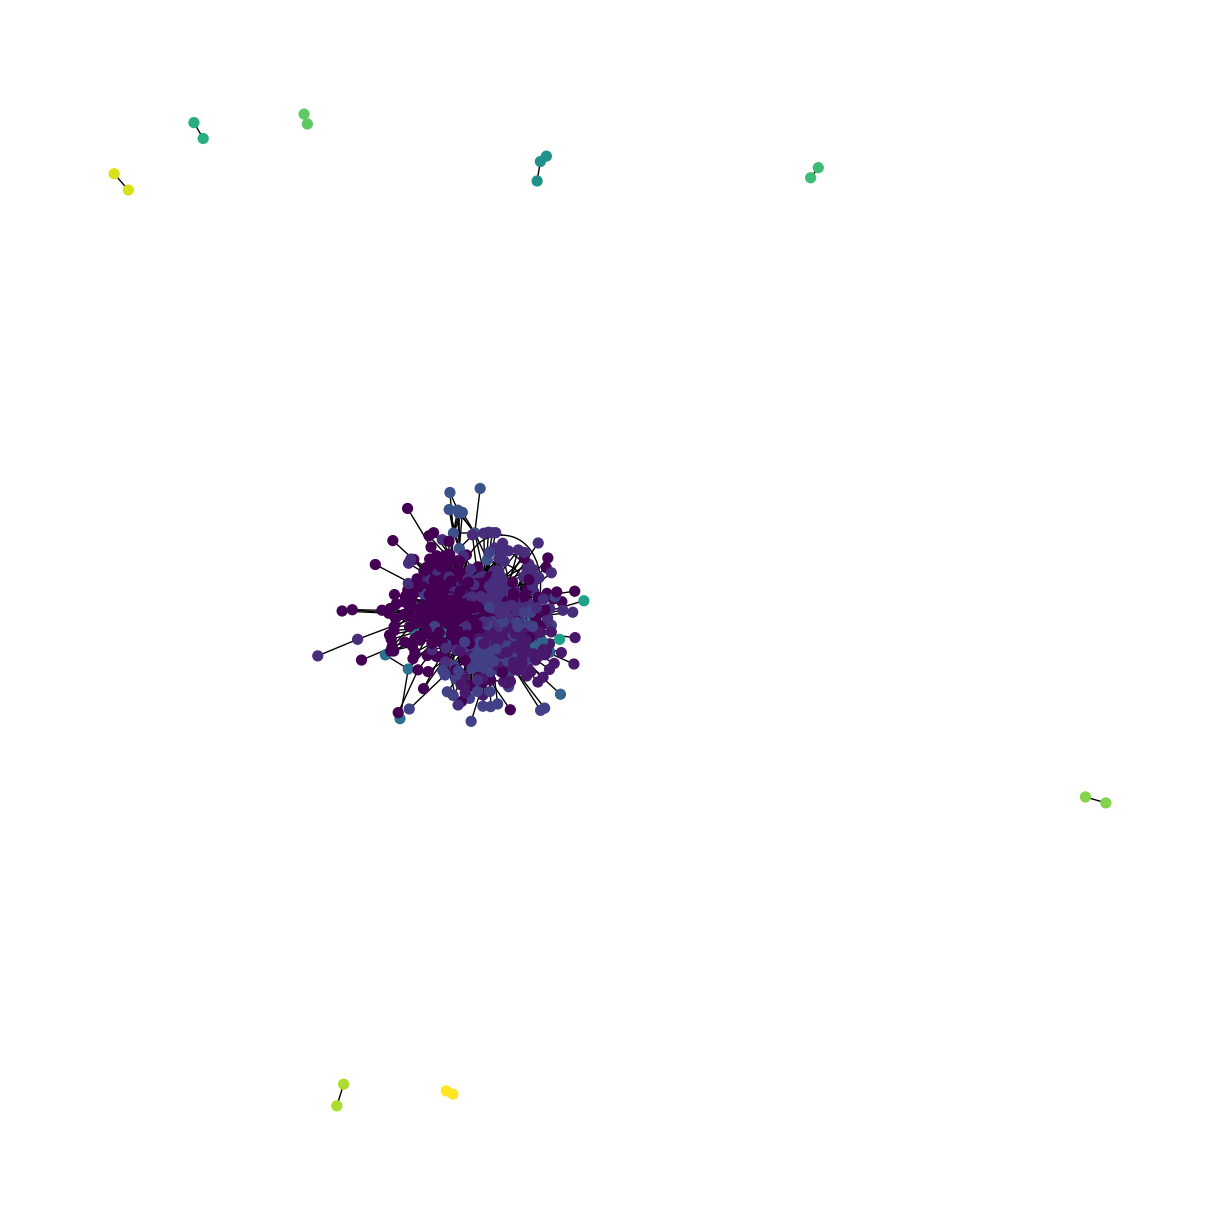

In [40]:
# Make a visualization of the follower network, coloring the nodes by community.
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i
colors = [color_map[node] for node in G.nodes()]
plt.figure(figsize=(12, 12))
# Layout with spring layout
nx.spring_layout(G, seed=42)
nx.draw(G, node_color=colors, with_labels=False, node_size=50, font_size=8)
plt.show()

In [36]:
# TF IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

other_posts_df = pd.read_csv('posters_other_posts.csv')
other_posts_df['text'] = other_posts_df['text'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')

# First, we'll get all of the text from the posters in each cluster, and then we'll use TF-IDF to identify the main topics of discussion for each cluster.

community_texts = []
for community in communities:
    community_text = ' '.join(other_posts_df[other_posts_df['poster'].isin(community)]['text'])
    community_texts.append(community_text)
tfidf_matrix = tfidf.fit_transform(community_texts)
feature_names = tfidf.get_feature_names_out()
for i, community in enumerate(communities):
    if len(community) < 5:  # Skip small communities
        continue
    print(f'Community {i}:')
    top_n = 20
    # Get the indices of the top n features for this community
    top_indices = tfidf_matrix[i].toarray()[0].argsort()[-top_n:][::-1] 
    # Get the words corresponding to the top indices
    top_features = [feature_names[index] for index in top_indices]
    print('\t' + '\n\t'.join(top_features))
    


Community 0:
	com
	www
	trump
	people
	https
	x1
	just
	like
	bsky
	newsbeep
	social
	2026
	don
	epstein
	state
	news
	new
	ice
	time
	know
Community 1:
	com
	like
	just
	michigan
	game
	people
	don
	www
	team
	time
	good
	think
	know
	football
	college
	going
	bsky
	hockey
	really
	season
Community 2:
	com
	www
	indiana
	iubb
	just
	like
	people
	purdue
	game
	bsky
	don
	https
	time
	social
	trump
	team
	good
	iu
	hoosiers
	news
Community 3:
	com
	www
	iowa
	game
	state
	just
	team
	basketball
	like
	season
	win
	michigan
	games
	today
	2026
	teams
	college
	vs
	good
	10
Community 4:
	memory
	palace
	thememor
	social
	bsky
	com
	today
	substack
	philsky
	philosophy
	pub
	university
	caic
	open
	philscisky
	research
	gencon
	www
	post
	org
Community 5:
	brewerfanatic
	brewers
	alert
	com
	ncaab
	forums
	watch
	icantfindthegame
	topic
	espn
	bsky
	soccer
	social
	2nd
	archived
	half
	just
	https
	people
	chourio


In [ ]:
df = pd.read_csv('./submissions.csv')

# Check if the output file exists. If not, create it and write the header.

if not os.path.exists('./comments.csv'):
    with open('./comments.csv', 'w') as f:
        out = csv.writer(f)
        out.writerow(['id',
                      'body',
                      'author', 
                      'created_utc', 
                      'parent_id', 
                      'submission_id', 
                      'tot_awards_received', 
                      'ups', 
                      'downs', 
                      'score'])

for submission_id in df.loc[df.comments_retrieved == False, 'id']:
    print(f'Retrieving comments for {submission_id}')
    submission = reddit.submission(id=submission_id)
    # This sets the limit to None, which means that it will retrieve all comments.
    submission.comments.replace_more(limit=None)
    # Because we're only storing whether a submission was retrieved, we save all the comments and write them at the same time.
    curr_comments = []
    for comment in submission.comments.list():
        try:
            name = comment.author.name
        except AttributeError:
            name = None
        curr_comments.append([comment.id, 
                        comment.body, 
                        name, 
                        comment.created_utc, 
                        comment.parent_id,
                        submission.id,
                        comment.total_awards_received,
                        comment.ups,
                        comment.downs,
                        comment.score
                        ])
    with open('./comments.csv', 'a') as f:
        out = csv.writer(f)
        out.writerows(curr_comments)
    df.loc[df.id == submission_id, 'comments_retrieved'] = True
    df.to_csv('./submissions.csv', index=False)